# B1, b2, b3 Comparison: 200 GeV vs 26 GeV (2 Hz)

| Dataset | Source |
|---------|--------|
| **200 GeV** | `MBB/2026-02-25_2Hz/200GeV` |
| **26 GeV** | `MBB/2026-02-25_2Hz/26GeV` |

| # | Section |
|---|---------|
| 1 | Configuration & Imports |
| 2 | Load Settled CSVs |
| 3 | B1 Comparison |
| 4 | b2, b3 Comparison |
| 5 | Multipole Spectrum Comparison |
| 6 | Statistical Significance |
| 7 | Summary |

---
## 1. Configuration & Imports

In [1]:
SEGMENTS = ['NCS', 'CS']

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib widget
plt.rcParams.update({"figure.figsize": (14, 5), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists(): break
    REPO_ROOT = REPO_ROOT.parent

OUT_0 = REPO_ROOT / "output" / "MBB/2026-02-25_2Hz/200GeV"
OUT_1 = REPO_ROOT / "output" / "MBB/2026-02-25_2Hz/26GeV"
assert OUT_0.exists(), f"200 GeV output not found: {OUT_0}"
assert OUT_1.exists(), f"26 GeV output not found: {OUT_1}"

DS_DIRS = [("200 GeV", OUT_0), ("26 GeV", OUT_1)]
print("Comparison: B1, b2, b3 Comparison: 200 GeV vs 26 GeV (2 Hz)")
for name, p in DS_DIRS:
    print(f"  {name}: {p}")

Comparison: B1, b2, b3 Comparison: 200 GeV vs 26 GeV (2 Hz)
  200 GeV: C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\200GeV
  26 GeV: C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\26GeV


---
## 2. Load Settled CSVs

In [2]:
ds = {}
for name, out_dir in DS_DIRS:
    ds[name] = {}
    for seg in SEGMENTS:
        fname = f"MBB_{seg}_streaming_settled.csv"
        fpath = out_dir / fname
        assert fpath.exists(), f"Missing: {fpath}"
        df = pd.read_csv(fpath)
        ds[name][seg] = df
        print(f"  {name} {seg}: {len(df)} settled turns")

# Also load eddy fit results if available
eddy_fits = {}
for name, out_dir in DS_DIRS:
    eddy_fits[name] = {}
    for seg in SEGMENTS:
        fpath = out_dir / f"b3_fits_{seg}.csv"
        if fpath.exists():
            eddy_fits[name][seg] = pd.read_csv(fpath)
            print(f"  {name} {seg} eddy fits: {len(eddy_fits[name][seg])} rows")
        else:
            eddy_fits[name][seg] = pd.DataFrame()

  200 GeV NCS: 532 settled turns
  200 GeV CS: 531 settled turns
  26 GeV NCS: 536 settled turns
  26 GeV CS: 537 settled turns
  26 GeV NCS eddy fits: 20 rows
  26 GeV CS eddy fits: 20 rows


---
## 3. B1 Comparison

Per-supercycle B1 at injection and flat-top.

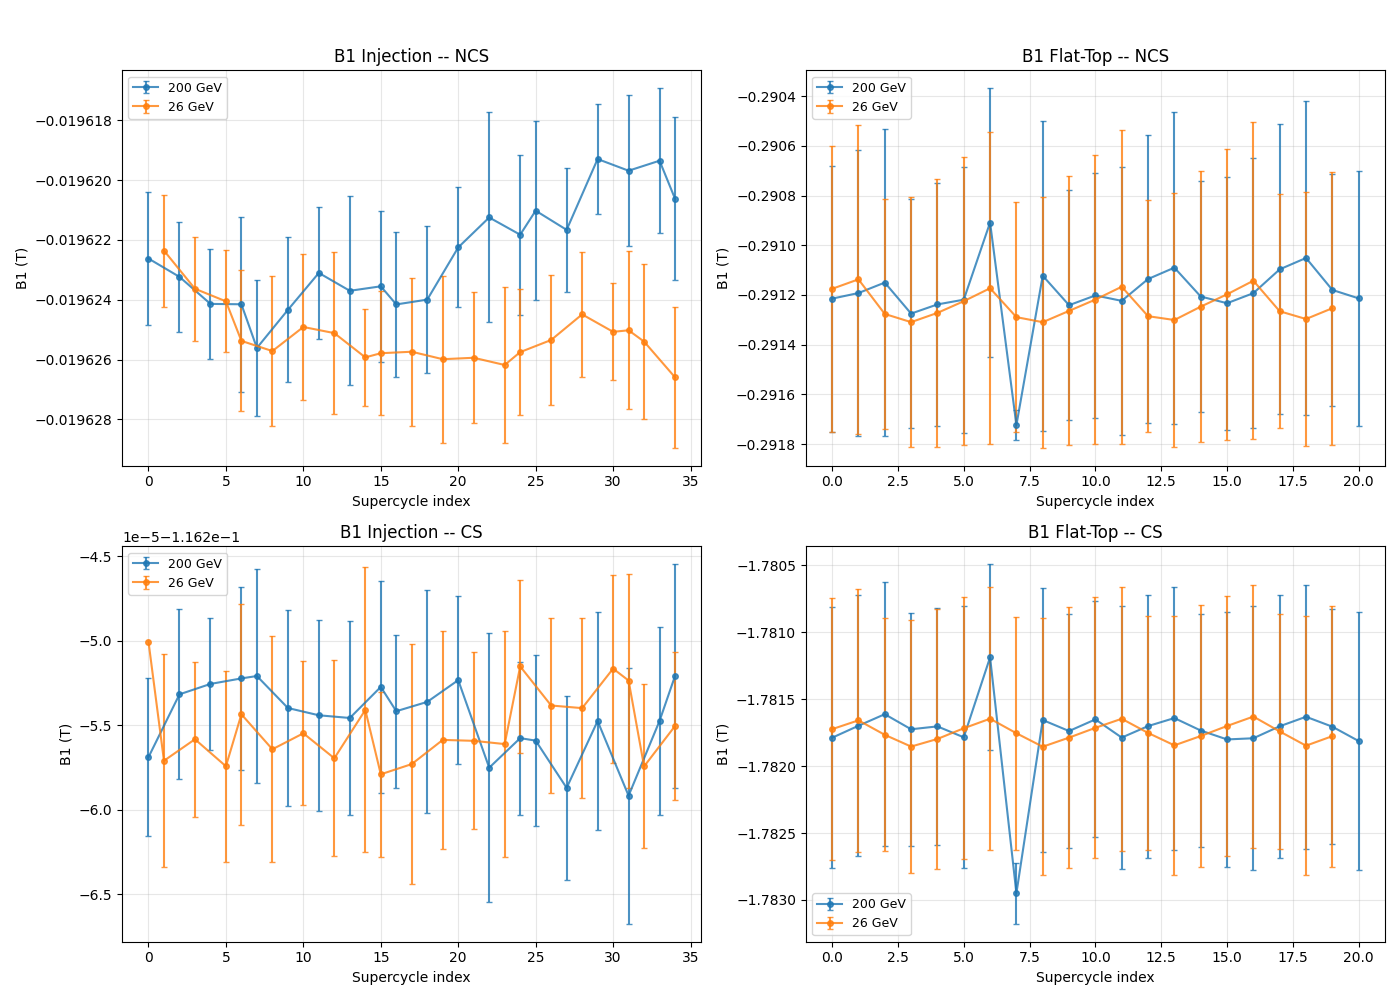

In [3]:
DS_COLORS = [("200 GeV", "tab:blue"), ("26 GeV", "tab:orange")]
fig, axes = plt.subplots(len(SEGMENTS), 2, figsize=(14, 5 * len(SEGMENTS)))
if len(SEGMENTS) == 1:
    axes = axes[np.newaxis, :]

for i, seg in enumerate(SEGMENTS):
    for j, (lab, title_suffix) in enumerate([("injection", "Injection"), ("flat-high", "Flat-Top")]):
        ax = axes[i, j]
        for ds_name, col in DS_COLORS:
            dfs = ds[ds_name][seg]
            sub = dfs[(dfs["label"] == lab) & dfs["ok_main"]]
            if len(sub) == 0: continue
            sc_avg = sub.groupby("sc_idx")["B1_T"].agg(["mean", "std"]).reset_index()
            ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                        fmt="o-", markersize=4, capsize=2, color=col, alpha=0.8, label=ds_name)
        ax.set_xlabel("Supercycle index"); ax.set_ylabel("B1 (T)")
        ax.set_title(f"B1 {title_suffix} -- {seg}"); ax.legend(fontsize=9)

fig.suptitle("B1 per Supercycle (settled)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 4. b2, b3 Comparison

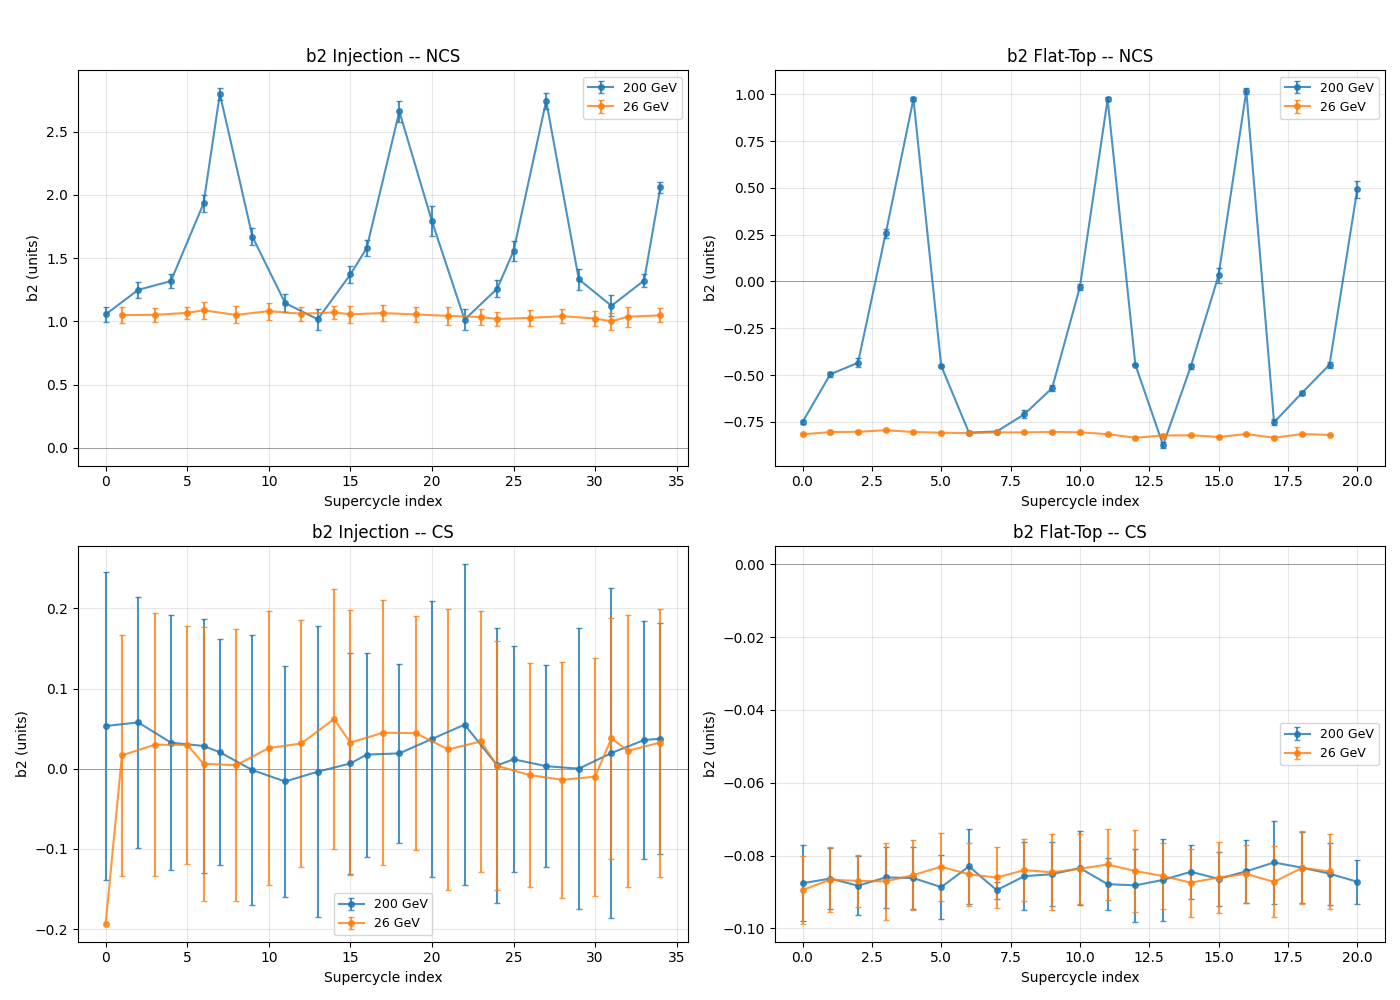

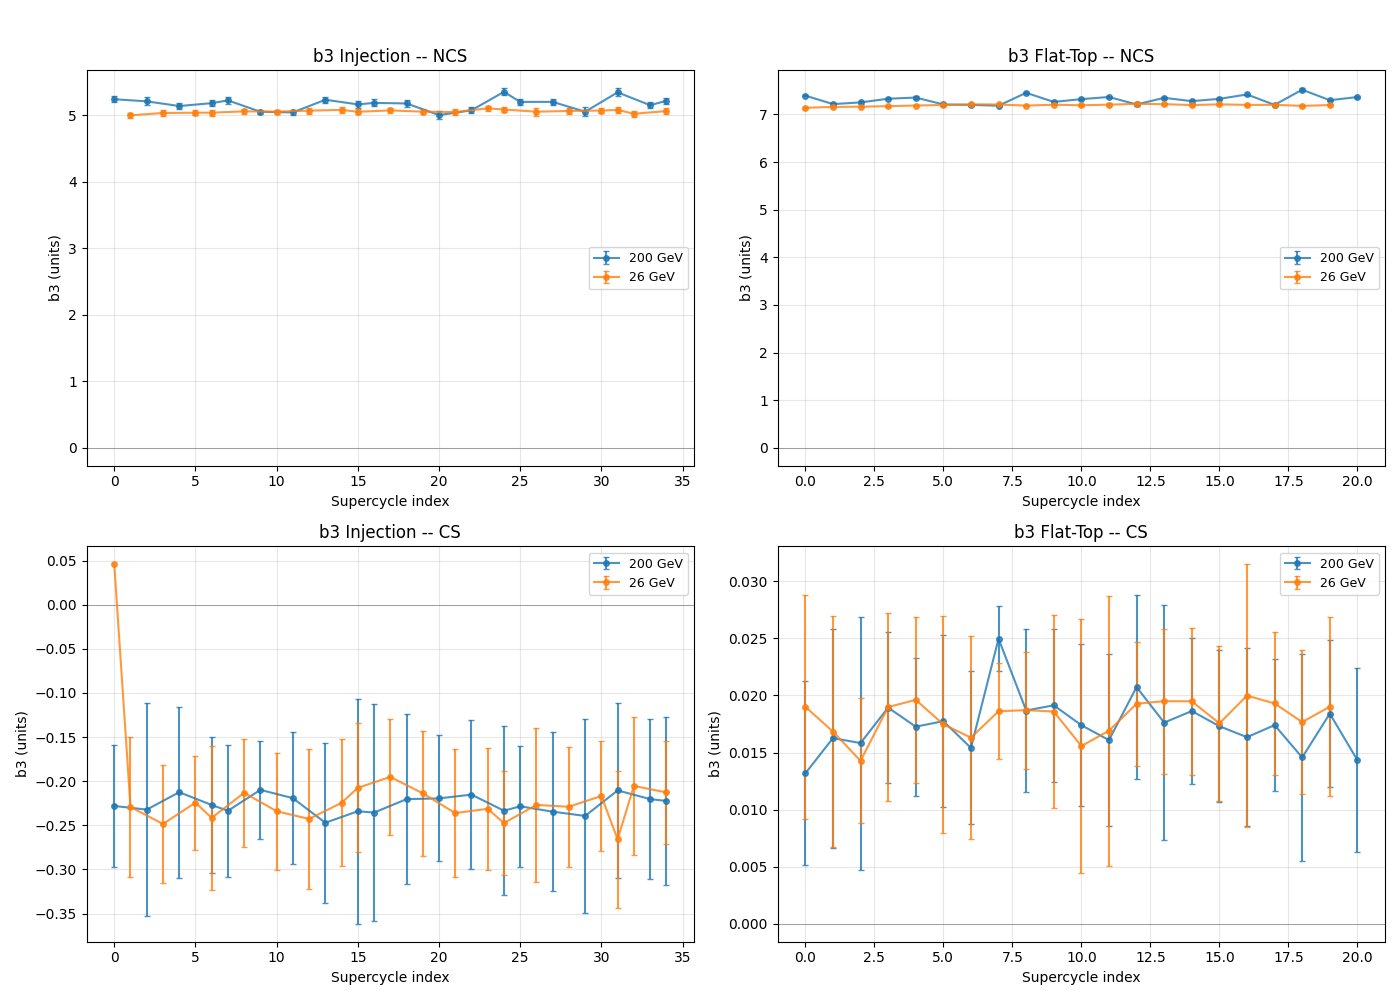

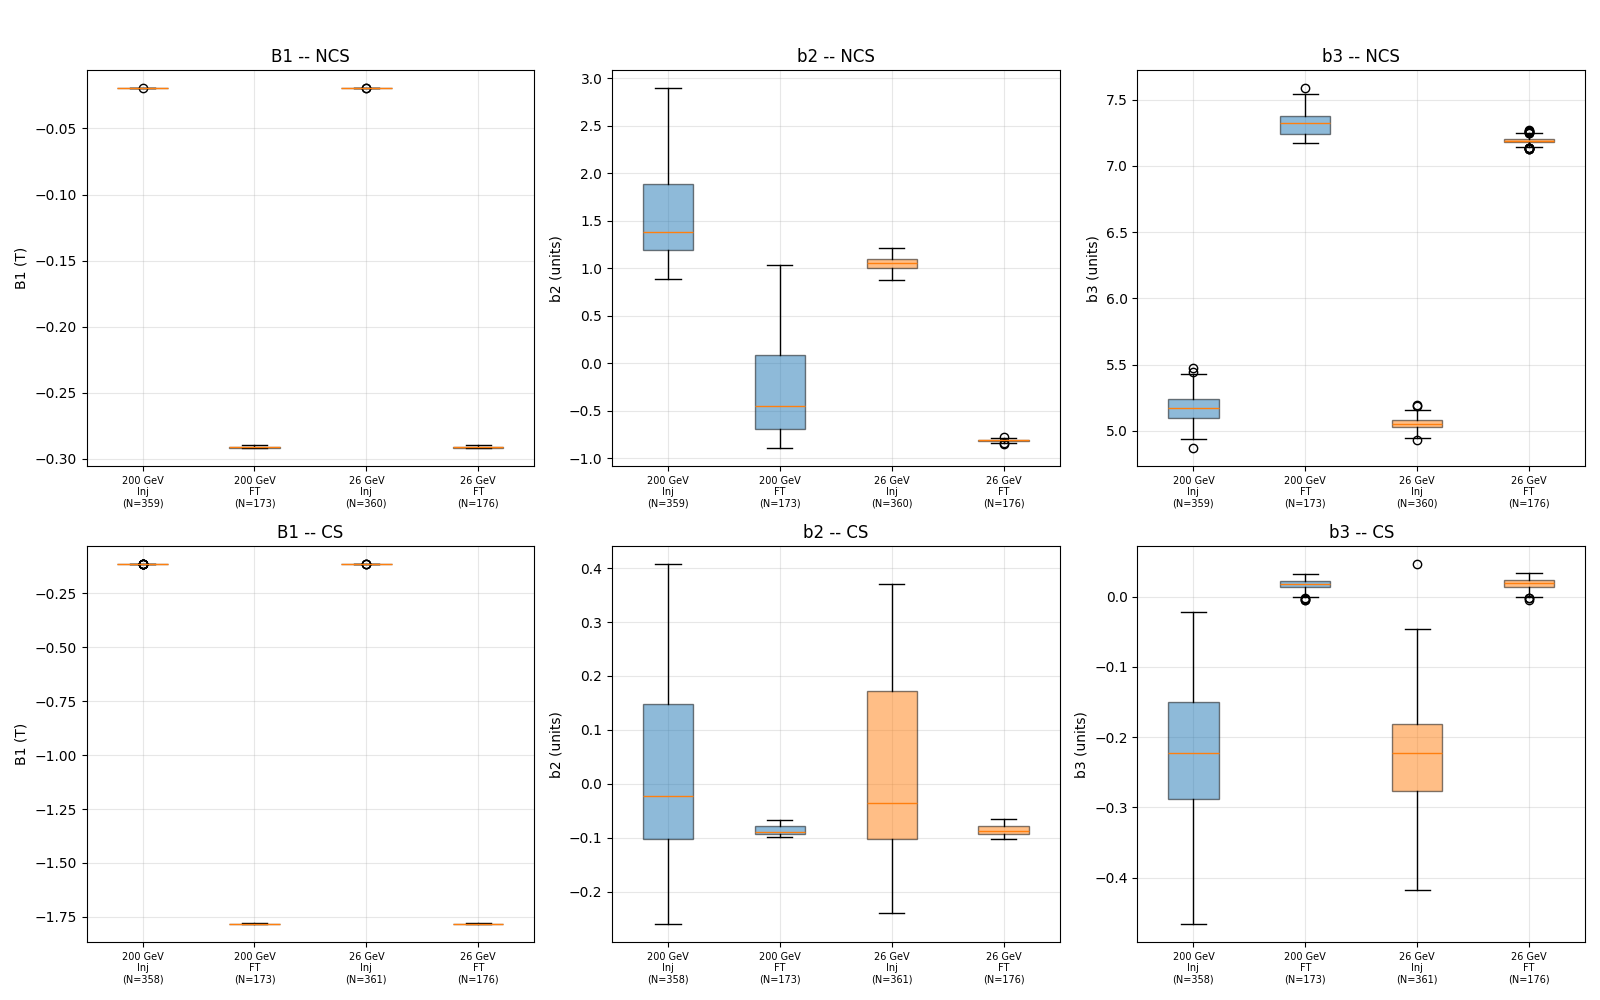

In [4]:
for harm_name, harm_col, ylabel in [("b2", "b2_units", "b2 (units)"), ("b3", "b3_units", "b3 (units)")]:
    fig, axes = plt.subplots(len(SEGMENTS), 2, figsize=(14, 5 * len(SEGMENTS)))
    if len(SEGMENTS) == 1:
        axes = axes[np.newaxis, :]

    for i, seg in enumerate(SEGMENTS):
        for j, (lab, title_suffix) in enumerate([("injection", "Injection"), ("flat-high", "Flat-Top")]):
            ax = axes[i, j]
            for ds_name, col in DS_COLORS:
                dfs = ds[ds_name][seg]
                sub = dfs[(dfs["label"] == lab) & dfs["ok_main"]]
                if len(sub) == 0: continue
                sc_avg = sub.groupby("sc_idx")[harm_col].agg(["mean", "std"]).reset_index()
                ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                            fmt="o-", markersize=4, capsize=2, color=col, alpha=0.8, label=ds_name)
            ax.axhline(0, color="grey", linewidth=0.5)
            ax.set_xlabel("Supercycle index"); ax.set_ylabel(ylabel)
            ax.set_title(f"{harm_name} {title_suffix} -- {seg}"); ax.legend(fontsize=9)

    fig.suptitle(f"{harm_name} per Supercycle (settled)", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

# Box plots
fig, axes = plt.subplots(len(SEGMENTS), 3, figsize=(16, 5 * len(SEGMENTS)))
if len(SEGMENTS) == 1:
    axes = axes[np.newaxis, :]

for i, seg in enumerate(SEGMENTS):
    for ax_idx, (col_name, ylabel, title) in enumerate([
            ("B1_T", "B1 (T)", "B1"), ("b2_units", "b2 (units)", "b2"), ("b3_units", "b3 (units)", "b3")]):
        ax = axes[i, ax_idx]
        box_data, box_labels, box_colors = [], [], []
        for ds_name, base_col in DS_COLORS:
            for lab, short in [("injection", "Inj"), ("flat-high", "FT")]:
                dfs = ds[ds_name][seg]
                sub = dfs[(dfs["label"] == lab) & dfs["ok_main"]]
                if len(sub) == 0: continue
                box_data.append(sub[col_name].values)
                box_labels.append(f"{ds_name}\n{short}\n(N={len(sub)})")
                box_colors.append(base_col)
        if box_data:
            bp = ax.boxplot(box_data, tick_labels=box_labels, patch_artist=True)
            for patch, col in zip(bp["boxes"], box_colors): patch.set_facecolor(col); patch.set_alpha(0.5)
        ax.set_ylabel(ylabel); ax.set_title(f"{title} -- {seg}")
        ax.tick_params(axis="x", labelsize=7)

fig.suptitle("Distribution Comparison (settled turns)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 5. Multipole Spectrum Comparison

Overlay normal harmonic spectra at injection (first segment).

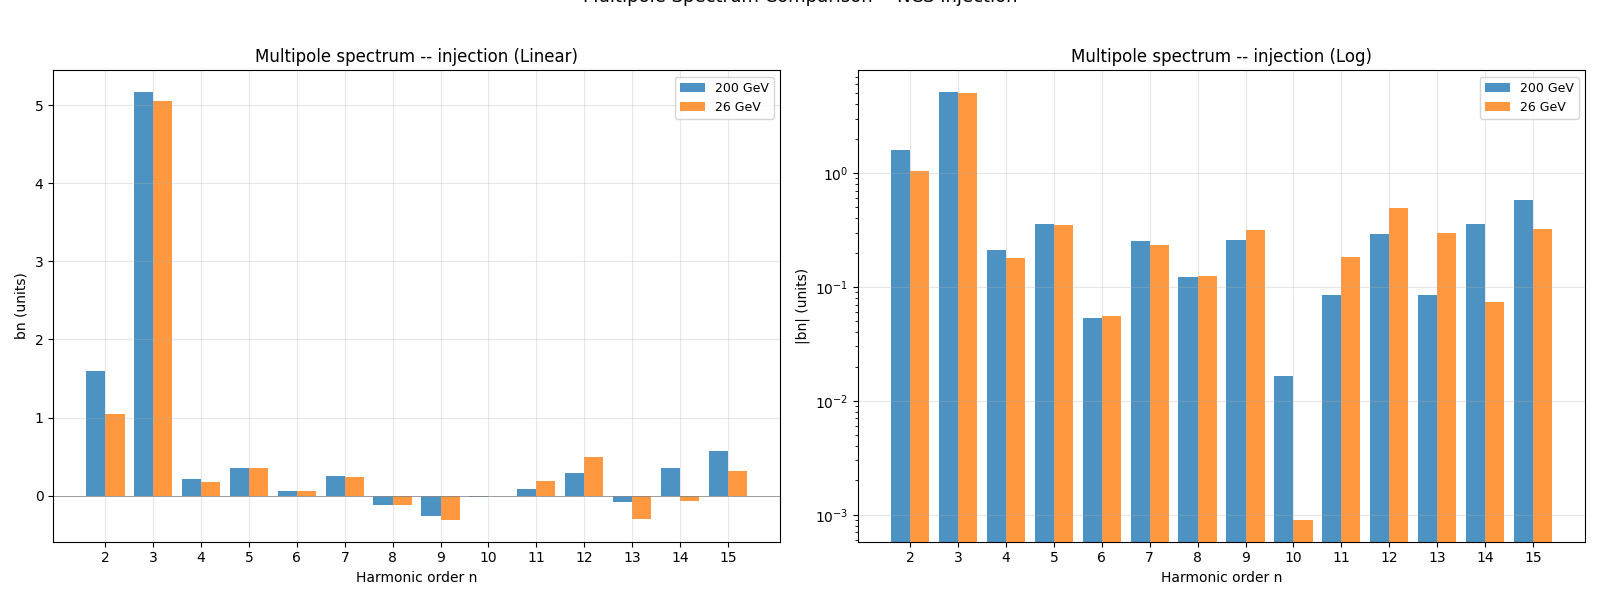

In [5]:
seg = SEGMENTS[0]
lab = "injection"

bn_cols = [c for c in ds[DS_DIRS[0][0]][seg].columns if c.startswith("b") and c.endswith("_units")]
orders = sorted([int(c.replace("b", "").replace("_units", "")) for c in bn_cols])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(orders))
w = 0.8 / len(DS_DIRS)

for ax_idx, (title, yscale) in enumerate([("Linear", "linear"), ("Log", "log")]):
    ax = axes[ax_idx]
    for k, (ds_name, color) in enumerate(DS_COLORS):
        dfs = ds[ds_name][seg]
        sub = dfs[(dfs["label"] == lab) & dfs["ok_main"]]
        if len(sub) == 0: continue
        means = [sub[f"b{n}_units"].mean() for n in orders]
        if yscale == "log":
            means = [abs(v) for v in means]
        ax.bar(x + (k - len(DS_DIRS)/2 + 0.5) * w, means, w, label=ds_name, color=color, alpha=0.8)
    if yscale == "linear":
        ax.axhline(0, color="grey", linewidth=0.5)
    else:
        ax.set_yscale("log")
    ax.set_xticks(x); ax.set_xticklabels(orders)
    ax.set_xlabel("Harmonic order n"); ax.set_ylabel("bn (units)" if yscale == "linear" else "|bn| (units)")
    ax.set_title(f"Multipole spectrum -- {lab} ({title})")
    ax.legend(fontsize=9)

fig.suptitle(f"Multipole Spectrum Comparison -- {seg} Injection", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 6. Statistical Significance

Sigma = |diff| / sqrt(std1^2/N1 + std2^2/N2). > 3 sigma = real difference.

In [6]:
NAME_A, NAME_B = DS_DIRS[0][0], DS_DIRS[1][0]
print(f"Difference: ({NAME_A}) - ({NAME_B})  [settled turns]")
print("=" * 110)
all_results = []

for seg in SEGMENTS:
    print(f"\n--- {seg} ---")
    for lab, desc in [("injection", "Injection"), ("flat-high", "Flat-Top")]:
        sA = ds[NAME_A][seg]
        sA = sA[(sA["label"] == lab) & sA["ok_main"]]
        sB = ds[NAME_B][seg]
        sB = sB[(sB["label"] == lab) & sB["ok_main"]]
        if len(sA) == 0 or len(sB) == 0: continue

        results_row = {"seg": seg, "label": lab, "desc": desc, "N_A": len(sA), "N_B": len(sB)}
        for name, col in [("B1", "B1_T"), ("b2", "b2_units"), ("b3", "b3_units")]:
            diff = sA[col].mean() - sB[col].mean()
            err = np.sqrt((sA[col].std()**2/len(sA)) + (sB[col].std()**2/len(sB)))
            sig = abs(diff) / err if err > 0 else 0
            results_row[f"d{name}"] = diff
            results_row[f"sig_{name}"] = sig
        all_results.append(results_row)

        print(f"  {desc:>12s}  dB1={results_row['dB1']:+.6f}  db2={results_row['db2']:+.4f}  "
              f"db3={results_row['db3']:+.4f}")
        print(f"  {'(sigma)':>12s}  {results_row['sig_B1']:>12.1f}  {results_row['sig_b2']:>14.1f}  "
              f"{results_row['sig_b3']:>14.1f}")

print("\nINTERPRETATION")
print("-" * 70)
for r in all_results:
    print(f"\n  {r['seg']} -- {r['desc']}  (N: {r['N_A']} vs {r['N_B']} turns)")
    for name, unit in [("B1", "T"), ("b2", "units"), ("b3", "units")]:
        diff = r[f"d{name}"]
        sig = r[f"sig_{name}"]
        verdict = "REAL (>3 sigma)" if sig > 3 else ("suggestive (2-3 sigma)" if sig >= 2 else "no evidence (<2 sigma)")
        diff_str = f"{diff*1e6:+.1f} uT" if unit == "T" else f"{diff:+.4f} {unit}"
        print(f"    {name:>3s}: {diff_str:>16s}  ({sig:.1f} sigma) -> {verdict}")

Difference: (200 GeV) - (26 GeV)  [settled turns]

--- NCS ---
     Injection  dB1=+0.000003  db2=+0.5524  db3=+0.1151
       (sigma)          13.5            18.5            19.3
      Flat-Top  dB1=+0.000061  db2=+0.6081  db3=+0.1250
       (sigma)           1.1            13.1            17.2

--- CS ---
     Injection  dB1=+0.000001  db2=-0.0010  db3=+0.0004
       (sigma)           1.6             0.1             0.1
      Flat-Top  dB1=+0.000034  db2=-0.0005  db3=-0.0010
       (sigma)           0.4             0.6             1.2

INTERPRETATION
----------------------------------------------------------------------

  NCS -- Injection  (N: 359 vs 360 turns)
     B1:          +2.7 uT  (13.5 sigma) -> REAL (>3 sigma)
     b2:    +0.5524 units  (18.5 sigma) -> REAL (>3 sigma)
     b3:    +0.1151 units  (19.3 sigma) -> REAL (>3 sigma)

  NCS -- Flat-Top  (N: 173 vs 176 turns)
     B1:         +61.0 uT  (1.1 sigma) -> no evidence (<2 sigma)
     b2:    +0.6081 units  (13.1 sigma) -> 

---
## 7. Summary

In [7]:
summary_rows = []
for ds_name, out_dir_path in DS_DIRS:
    for seg in SEGMENTS:
        dfs = ds[ds_name][seg]
        for lab, desc in [("injection", "Injection"), ("flat-high", "Flat-Top")]:
            sub = dfs[(dfs["label"] == lab) & dfs["ok_main"]]
            if len(sub) == 0: continue
            tf = sub["B1_T"].mean() / (sub["I_mean_A"].mean() / 1000.0) if "I_mean_A" in sub.columns else np.nan
            summary_rows.append({
                "Dataset": ds_name, "Segment": seg, "Op. point": desc,
                "N turns": len(sub),
                "I mean (A)": f"{sub['I_mean_A'].mean():.1f}" if "I_mean_A" in sub.columns else "-",
                "B1 mean (T)": f"{sub['B1_T'].mean():.6f}", "B1 std (T)": f"{sub['B1_T'].std():.6f}",
                "b2 mean": f"{sub['b2_units'].mean():+.4f}", "b3 mean": f"{sub['b3_units'].mean():+.4f}",
                "TF (T/kA)": f"{tf:.4f}" if not np.isnan(tf) else "-",
            })
df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

# Export comparison summary
out_dir = REPO_ROOT / "output" / "MBB/2026-02-25_2Hz/compare_200_vs_26"
out_dir.mkdir(parents=True, exist_ok=True)
df_summary.to_csv(out_dir / "summary_comparison_settled.csv", index=False)
print(f"\nWrote {out_dir / 'summary_comparison_settled.csv'}")
print("\nDone.")

Dataset Segment Op. point  N turns I mean (A) B1 mean (T) B1 std (T) b2 mean b3 mean TF (T/kA)
200 GeV     NCS Injection      359      300.9   -0.019622   0.000003 +1.6006 +5.1706   -0.0652
200 GeV     NCS  Flat-Top      173     4814.6   -0.291179   0.000520 -0.2055 +7.3184   -0.0605
200 GeV      CS Injection      358      300.9   -0.116255   0.000006 +0.0210 -0.2261   -0.3864
200 GeV      CS  Flat-Top      173     4814.6   -1.781715   0.000901 -0.0859 +0.0171   -0.3701
 26 GeV     NCS Injection      360      300.9   -0.019625   0.000002 +1.0482 +5.0555   -0.0652
 26 GeV     NCS  Flat-Top      176     4814.6   -0.291240   0.000523 -0.8136 +7.1934   -0.0605
 26 GeV      CS Injection      361      300.9   -0.116255   0.000006 +0.0220 -0.2265   -0.3863
 26 GeV      CS  Flat-Top      176     4814.6   -1.781749   0.000906 -0.0854 +0.0181   -0.3701

Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\compare_200_vs_26\summary_comparison_settled.csv

Done.